# Celda 0: Configuración inicial (Importaciones)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')

# Paso 1: Representaciones Visuales de Redes de Reacción

## ¿Qué estamos haciendo?
Antes de escribir una sola línea de matemáticas, necesitamos entender la biología. En la primera imagen observamos un **modelo de juguete** que representa una red de reacciones. 

## Interpretación Biológica:
*   **Sustrato (\(X_{pre}\))**: Es el material de partida que el sistema tiene disponible para producir la Proteína \(X\).
*   **Proteína \(X\)**: Se produce (\(R1\)) y se degrada (\(R2\)). Su cantidad depende de la producción y la degradación.
*   **Proteína \(Y\)**: Se une a \(X\) para formar un dímero (\(XY\)).
*   **Dímero \(XY\)**: Es el producto de la unión de \(X\) e \(Y\). También puede disociarse y volver a sus componentes originales (\(R3-\)).
*   **Moduladores (Cuadros azules)**: \(E_{prod}\), \(E_{deg}\), \(E_{dim}\) y \(E_{dis}\) actúan como "perillas" o enzimas que aceleran o frenan las reacciones (rombos verdes).

## Guía:
Observa el diagrama. Cada flecha es una reacción. Los rombos verdes (\(R1, R2, R3\)) son las velocidades de esas reacciones. Antes de resolver matemáticamente, pregúntate: *¿Qué pasa con la cantidad de \(X\) si aumento \(E_{prod}\)? ¿Qué pasa con \(Y\) si \(X\) se une mucho a ella?*

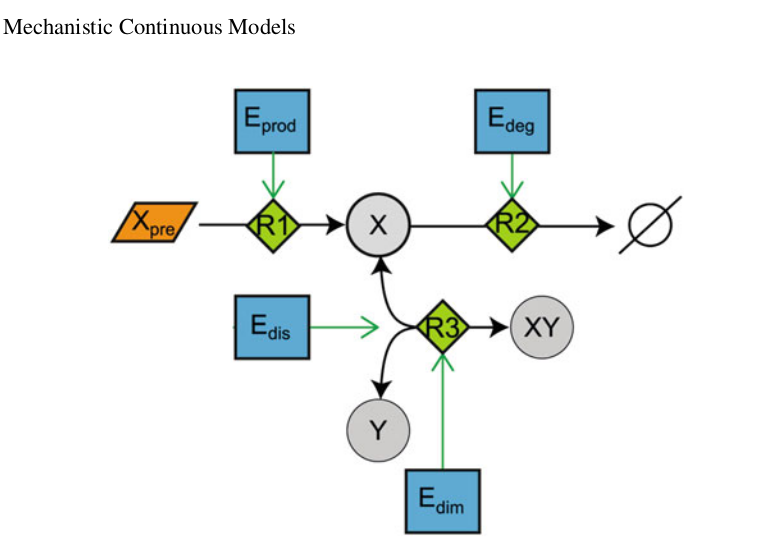

# Paso 2: Representación Matemática (EDOs)

## ¿Qué estamos haciendo?
Traducimos el diagrama de la red a un lenguaje que las computadoras entiendan: **Ecuaciones Diferenciales Ordinarias (EDOs)**. 

## Interpretación Matemática:
Aplicamos la **Ley de Acción de Masas**. La tasa de cambio de una especie (\(\frac{dX}{dt}\)) es igual a la suma de sus reacciones de formación menos sus reacciones de consumo.

Para la Proteína \(X\):
*   **A favor (+):** Se produce (\(X_{pre} k_{prod} E_{prod}\)) y el dímero se disocia (\(XY k_{dis} E_{dis}\)).
*   **En contra (-):** Se degrada (\(X k_{deg} E_{deg}\)) y se une a \(Y\) para formar el dímero (\(X Y k_{dim} E_{dim}\)).

Las ecuaciones completas del sistema son:

$$ \frac{dX(t)}{dt} = X_{pre} k_{prod} E_{prod} - X(t) k_{deg} E_{deg} - X(t)Y(t) k_{dim} E_{dim} + XY(t) k_{dis} E_{dis} $$

$$ \frac{dY(t)}{dt} = -X(t)Y(t) k_{dim} E_{dim} + XY(t) k_{dis} E_{dis} $$

$$ \frac{dXY(t)}{dt} = X(t)Y(t) k_{dim} E_{dim} - XY(t) k_{dis} E_{dis} $$

## Guía:
Fíjate en los signos. Cada término positivo representa una flecha que *entra* al nodo (\(X\), \(Y\) o \(XY\)), y cada término negativo representa una flecha que *sale* del nodo. La constante \(k\) indica la afinidad o velocidad intrínseca de la reacción, y \(E\) indica la modulación externa.

# Paso 3: Simplificación del Modelo (Ecuaciones de Conservación)

## ¿Qué estamos haciendo?
En biología, muchas veces las moléculas no se destruyen, solo cambian de estado. El sistema original tiene 3 ecuaciones (\(X\), \(Y\), \(XY\)), pero podemos simplificarlo a 2. ¡Menos ecuaciones significa computación más rápida y menos errores numéricos!

## Interpretación Matemática:
La cantidad total de la Proteína \(Y\) en el sistema es constante. La \(Y\) está en dos estados: libre (\(Y\)) o unida al dímero (\(XY\)). 
Por lo tanto, la ecuación de conservación es:

$$ Y_T = Y(t) + XY(t) = \text{constante} $$

Al derivar esto con respecto al tiempo, obtenemos:

$$ \frac{dY_T}{dt} = \frac{dY(t)}{dt} + \frac{dXY(t)}{dt} = 0 $$

Esto nos permite reemplazar \(XY(t)\) con \((Y_T - Y(t))\) en la ecuación de \(X\), eliminando una variable del sistema y reduciendo el problema de 3D a 2D:

$$ \frac{dX(t)}{dt} = X_{pre} k_{prod} E_{prod} - X(t) k_{deg} E_{deg} - X(t)Y(t) k_{dim} E_{dim} + (Y_T - Y(t)) k_{dis} E_{dis} $$

$$ \frac{dY(t)}{dt} = -X(t)Y(t) k_{dim} E_{dim} + (Y_T - Y(t)) k_{dis} E_{dis} $$

## Guía:
Ejecuta el código interactivo. Mueve el slider de \(Y_T\). Observa cómo la línea negra punteada (la suma de \(Y\) y \(XY\)) se mantiene completamente plana sin importar el tiempo. La materia no se crea ni se destruye, solo se transforma.

In [10]:
display(Markdown("## Paso 3: Simplificación del Modelo y Conservación"))

def verificar_conservacion(Y_T=100, t_max=20):
    # Simulamos un sistema simple para demostrar que Y + XY = Y_T
    # Usamos valores arbitrarios para las constantes solo para la demostración visual
    params = [10, 1, 1, 0.5, 1, 0.1, 1, 0.05, 1, Y_T]
    
    def sys(y, t, p):
        X, Y = y
        X_pre, k_prod, E_prod, k_deg, E_deg, k_dim, E_dim, k_dis, E_dis, Y_T = p
        dXdt = X_pre*k_prod*E_prod - X*k_deg*E_deg - X*Y*k_dim*E_dim + (Y_T - Y)*k_dis*E_dis
        dYdt = -X*Y*k_dim*E_dim + (Y_T - Y)*k_dis*E_dis
        return [dXdt, dYdt]

    t = np.linspace(0, t_max, 100)
    # Condiciones iniciales: X=0, Y=Y_T (todo libre al inicio)
    y0 = [0, Y_T] 
    sol = odeint(sys, y0, t, args=(params,))
    
    X_sol = sol[:, 0]
    Y_sol = sol[:, 1]
    XY_sol = Y_T - Y_sol # Usando la ecuación de conservación
    
    plt.figure(figsize=(10, 4))
    plt.plot(t, Y_sol, label='Y(t)')
    plt.plot(t, XY_sol, label='XY(t)')
    plt.plot(t, Y_sol + XY_sol, 'k--', label='Y(t) + XY(t) = \(Y_T\)')
    plt.title('Verificación de la Ecuación de Conservación')
    plt.xlabel('Tiempo')
    plt.ylabel('Concentración')
    plt.legend()
    plt.show()

widgets.interact(verificar_conservacion, 
                 Y_T=widgets.FloatSlider(value=100, min=10, max=200, step=10, description='\(Y_T\):'))

## Paso 3: Simplificación del Modelo y Conservación

interactive(children=(FloatSlider(value=100.0, description='\\(Y_T\\):', max=200.0, min=10.0, step=10.0), IntS…

<function __main__.verificar_conservacion(Y_T=100, t_max=20)>

# Paso 4: Identificación de Condiciones Iniciales y Parámetros

## ¿Qué estamos haciendo?
Para que un modelo funcione, necesitamos darle un punto de partida (condiciones iniciales) y definir las reglas de velocidad (parámetros). 

## Interpretación Biológica y Matemática:
*   **Condiciones Iniciales (\(X_0, Y_0\))**: ¿Cuánta proteína \(X\) y \(Y\) hay en el momento en que empezamos a observar la célula (\(t=0\))? Matemáticamente: \(X(0) = X_0\) y \(Y(0) = Y_0\).
*   **Parámetros (\(k\) y \(E\))**: Son los valores numéricos que definen qué tan rápido ocurren las reacciones. En un experimento real, estos se miden o se estiman. Por ejemplo, \(k_{prod}\) es la tasa de producción base, mientras que \(E_{prod}\) es el nivel de modulación (ej. presencia de un factor de transcripción).

## Guía:
Juega con los sliders. Los cuadros azules originales (\(E_{prod}\), \(E_{deg}\), etc.) son parámetros de modulación. Si aumentas \(E_{deg}\) (la enzima que degrada \(X\)), ¿qué crees que le pasará a la concentración de \(X\) en el futuro? Aún no lo simulamos, pero usa tu intuición biológica.


In [4]:
display(Markdown("## Paso 4: Condiciones Iniciales y Parámetros"))
display(Markdown("Ajusta los parámetros y observa cómo se definen. En los siguientes pasos evaluaremos su efecto."))

# Definimos los sliders
X_pre_slider = widgets.FloatSlider(value=10, min=0, max=50, step=1, description='\(X_{pre}\):')
k_prod_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='\(k_{prod}\):')
E_prod_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='\(E_{prod}\):')
k_deg_slider = widgets.FloatSlider(value=0.5, min=0.1, max=5.0, step=0.1, description='\(k_{deg}\):')
E_deg_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='\(E_{deg}\):')
k_dim_slider = widgets.FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description='\(k_{dim}\):')
E_dim_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='\(E_{dim}\):')
k_dis_slider = widgets.FloatSlider(value=0.05, min=0.01, max=1.0, step=0.01, description='\(k_{dis}\):')
E_dis_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='\(E_{dis}\):')
Y_T_slider = widgets.FloatSlider(value=100, min=10, max=200, step=10, description='\(Y_T\):')
X0_slider = widgets.FloatSlider(value=0, min=0, max=50, step=1, description='\(X_0\):')
Y0_slider = widgets.FloatSlider(value=100, min=0, max=200, step=10, description='\(Y_0\):')

def mostrar_parametros(X_pre, k_prod, E_prod, k_deg, E_deg, k_dim, E_dim, k_dis, E_dis, Y_T, X0, Y0):
    print("Parámetros seleccionados:")
    print(f"Protección: X_pre={X_pre}, k_prod={k_prod}, E_prod={E_prod}")
    print(f"Degradación: k_deg={k_deg}, E_deg={E_deg}")
    print(f"Dimerización: k_dim={k_dim}, E_dim={E_dim}")
    print(f"Disociación: k_dis={k_dis}, E_dis={E_dis}")
    print(f"Conservación: Y_T={Y_T}")
    print(f"Condiciones Iniciales: X0={X0}, Y0={Y0}")

widgets.interact(mostrar_parametros, 
                 X_pre=X_pre_slider, k_prod=k_prod_slider, E_prod=E_prod_slider,
                 k_deg=k_deg_slider, E_deg=E_deg_slider,
                 k_dim=k_dim_slider, E_dim=E_dim_slider,
                 k_dis=k_dis_slider, E_dis=E_dis_slider,
                 Y_T=Y_T_slider, X0=X0_slider, Y0=Y0_slider)

## Paso 4: Condiciones Iniciales y Parámetros

Ajusta los parámetros y observa cómo se definen. En los siguientes pasos evaluaremos su efecto.

interactive(children=(FloatSlider(value=10.0, description='\\(X_{pre}\\):', max=50.0, step=1.0), FloatSlider(v…

<function __main__.mostrar_parametros(X_pre, k_prod, E_prod, k_deg, E_deg, k_dim, E_dim, k_dis, E_dis, Y_T, X0, Y0)>

# Paso 5: Comportamiento de Equilibrio (Estado Estacionario)

## ¿Qué estamos haciendo?
Buscamos el "destino final" del sistema. El estado estacionario ocurre cuando el sistema se estabiliza y las concentraciones ya no cambian con el tiempo.

## Interpretación Matemática:
Matemáticamente, esto significa igualar las derivadas a cero: \(\frac{dX}{dt} = 0\) y \(\frac{dY}{dt} = 0\). Al resolver este sistema de ecuaciones algebraicas, encontramos las concentraciones de equilibrio (\(X^*\), \(Y^*\), \(XY^*\)).

Para \(X\), el estado estacionario es simplemente la producción dividida por la degradación:
$$ X^* = \frac{X_{pre} k_{prod} E_{prod}}{k_{deg} E_{deg}} $$

Para \(Y\), el equilibrio depende de la competencia entre la dimerización y la disociación:
$$ Y^* = \frac{Y_T k_{dis} E_{dis}}{X^* k_{dim} E_{dim} + k_{dis} E_{dis}} $$

Y por conservación, sabemos que:
$$ XY^* = Y_T - Y^* $$

## Guía:
Mueve los sliders y observa el gráfico de barras. ¿Qué pasa con \(X^*\) si aumentas drásticamente \(k_{prod}\)? (Aumenta proporcionalmente). ¿Qué pasa con \(Y^*\) si aumentas \(X^*\)? (Disminuye, porque más \(X\) libre atrapa a la \(Y\) para formar el dímero).

In [5]:
display(Markdown("## Paso 5: Análisis de Estado Estacionario"))
display(Markdown("En el estado estacionario, $dX/dt = 0$ y $dY/dt = 0$. Analíticamente llegamos a:"))
display(Markdown("$$ X^* = \\frac{X_{pre} k_{prod} E_{prod}}{k_{deg} E_{deg}} $$"))
display(Markdown("$$ Y^* = \\frac{Y_T k_{dis} E_{dis}}{X^* k_{dim} E_{dim} + k_{dis} E_{dis}} $$"))

def calcular_estado_estacionario(X_pre, k_prod, E_prod, k_deg, E_deg, k_dim, E_dim, k_dis, E_dis, Y_T):
    # Cálculo de X en equilibrio
    X_eq = (X_pre * k_prod * E_prod) / (k_deg * E_deg)
    # Cálculo de Y en equilibrio
    Y_eq = (Y_T * k_dis * E_dis) / (X_eq * k_dim * E_dim + k_dis * E_dis)
    XY_eq = Y_T - Y_eq
    
    print(f"Estado Estacionario:")
    print(f"X* = {X_eq:.2f}")
    print(f"Y* = {Y_eq:.2f}")
    print(f"XY* = {XY_eq:.2f}")
    
    # Gráfico de barras simple
    plt.figure(figsize=(6, 4))
    plt.bar(['X*', 'Y*', 'XY*'], [X_eq, Y_eq, XY_eq], color=['#4C72B0', '#DD8452', '#55A868'])
    plt.title('Concentraciones en Estado Estacionario')
    plt.ylabel('Concentración')
    plt.show()

widgets.interact(calcular_estado_estacionario,
                 X_pre=X_pre_slider, k_prod=k_prod_slider, E_prod=E_prod_slider,
                 k_deg=k_deg_slider, E_deg=E_deg_slider,
                 k_dim=k_dim_slider, E_dim=E_dim_slider,
                 k_dis=k_dis_slider, E_dis=E_dis_slider,
                 Y_T=Y_T_slider)

## Paso 5: Análisis de Estado Estacionario

En el estado estacionario, $dX/dt = 0$ y $dY/dt = 0$. Analíticamente llegamos a:

$$ X^* = \frac{X_{pre} k_{prod} E_{prod}}{k_{deg} E_{deg}} $$

$$ Y^* = \frac{Y_T k_{dis} E_{dis}}{X^* k_{dim} E_{dim} + k_{dis} E_{dis}} $$

interactive(children=(FloatSlider(value=10.0, description='\\(X_{pre}\\):', max=50.0, step=1.0), FloatSlider(v…

<function __main__.calcular_estado_estacionario(X_pre, k_prod, E_prod, k_deg, E_deg, k_dim, E_dim, k_dis, E_dis, Y_T)>

# Paso 6: Simulación Dinámica del Sistema de EDOs

## ¿Qué estamos haciendo?
El estado estacionario nos dice *a dónde* vamos, pero la simulación dinámica nos dice *cómo* llegamos allí. Resolvemos las EDOs numéricamente a lo largo del tiempo usando `scipy.integrate.odeint`.

## Interpretación Computacional:
La computadora divide el tiempo en pequeños pasos (ej. de \(t=0\) a \(t=50\)) y calcula cómo cambian \(X(t)\), \(Y(t)\) y \(XY(t)\) en cada paso. Esto genera las curvas de concentración vs tiempo.

$$ \frac{dX(t)}{dt} = f(X, Y, t) $$
$$ \frac{dY(t)}{dt} = g(X, Y, t) $$

## Guía:
Ejecuta la simulación. Compara las curvas dinámicas con las barras del Paso 5. 
* ¿Las curvas se estabilizan en los mismos valores que predijo el estado estacionario? (Deberían).
* Observa la rapidez con la que sube \(X\). ¿Qué parámetro controla esa pendiente inicial? (Prueba cambiando \(k_{prod}\) y \(k_{deg}\)).

In [ ]:
display(Markdown("## Paso 6: Simulación Dinámica"))
display(Markdown("Resolvemos numéricamente el sistema de EDOs usando `scipy.integrate.odeint`."))

def simulacion_dinamica(Y_T, X0, k_prod, k_deg, k_dim, k_dis, t_max=50):
    # Parámetros fijos para simplificar la simulación
    X_pre = 10; E_prod = 1; E_deg = 1; E_dim = 1; E_dis = 1
    
    params = [X_pre, k_prod, E_prod, k_deg, E_deg, k_dim, E_dim, k_dis, E_dis, Y_T]
    
    def sys(y, t, p):
        X, Y = y
        X_pre, k_prod, E_prod, k_deg, E_deg, k_dim, E_dim, k_dis, E_dis, Y_T = p
        dXdt = X_pre*k_prod*E_prod - X*k_deg*E_deg - X*Y*k_dim*E_dim + (Y_T - Y)*k_dis*E_dis
        dYdt = -X*Y*k_dim*E_dim + (Y_T - Y)*k_dis*E_dis
        return [dXdt, dYdt]

    t = np.linspace(0, t_max, 200)
    y0 = [X0, Y_T] # Asumimos que Y inicial es todo el Y_T disponible
    sol = odeint(sys, y0, t, args=(params,))
    
    X_sol = sol[:, 0]
    Y_sol = sol[:, 1]
    XY_sol = Y_T - Y_sol
    
    plt.figure(figsize=(10, 5))
    plt.plot(t, X_sol, label='X(t)', linewidth=2)
    plt.plot(t, Y_sol, label='Y(t)', linewidth=2)
    plt.plot(t, XY_sol, label='XY(t)', linewidth=2)
    plt.title('Dinámica del Sistema de EDOs')
    plt.xlabel('Tiempo')
    plt.ylabel('Concentración')
    plt.legend()
    plt.grid(True)
    plt.show()

widgets.interact(simulacion_dinamica,
                 Y_T=widgets.FloatSlider(value=100, min=10, max=200, step=10, description='\(Y_T\):'),
                 X0=widgets.FloatSlider(value=0, min=0, max=50, step=1, description='\(X_0\):'),
                 k_prod=widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='\(k_{prod}\):'),
                 k_deg=widgets.FloatSlider(value=0.5, min=0.1, max=5.0, step=0.1, description='\(k_{deg}\):'),
                 k_dim=widgets.FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description='\(k_{dim}\):'),
                 k_dis=widgets.FloatSlider(value=0.05, min=0.01, max=1.0, step=0.01, description='\(k_{dis}\):'))

## Paso 6: Simulación Dinámica

Resolvemos numéricamente el sistema de EDOs usando `scipy.integrate.odeint`.

interactive(children=(FloatSlider(value=100.0, description='\\(Y_T\\):', max=200.0, min=10.0, step=10.0), Floa…

<function __main__.simulacion_dinamica(Y_T, X0, k_prod, k_deg, k_dim, k_dis, t_max=50)>

# Paso 7: Optimización de Parámetros

## ¿Qué estamos haciendo?
En la vida real, no conocemos los valores exactos de \(k_{prod}\) o \(k_{deg}\). Lo que tenemos son **datos experimentales** (puntos rojos con ruido). La optimización busca los parámetros que hacen que nuestro modelo se ajuste mejor a esos datos.

## Interpretación Matemática:
Definimos una función de costo, típicamente el **Error Cuadrático** (SSE, por sus siglas en inglés), que mide la distancia entre los datos experimentales (\(X_{exp}\)) y la predicción del modelo (\(X_{model}\)):

$$ SSE = \sum_{i=1}^{N} (X_{exp,i} - X_{model,i})^2 $$

Usamos un algoritmo de minimización (como el descenso de gradiente) para encontrar el valor de \(k_{prod}\) que minimiza esta función: \(\min_{k_{prod}} SSE\).

## Guía:
Mueve el slider de \(k_{prod}\). Tu objetivo es hacer que la línea azul (modelo) pase lo más cerca posible de los puntos rojos (datos experimentales). Fíjate en el valor del "Error Cuadrático Total" en el título del gráfico. ¿Cuál es el valor de \(k_{prod}\) que da el error más bajo? Ese es el parámetro óptimo.


In [ ]:
display(Markdown("## Paso 7: Optimización de Parámetros"))
display(Markdown("Generamos datos 'experimentales' sintéticos con ruido y ajustamos un parámetro (ej. \(k_{prod}\)) para minimizar el error cuadrático."))

# Datos "experimentales" generados con ruido
np.random.seed(42)
t_exp = np.linspace(0, 30, 15)
Y_T_real = 100
X_pre_real = 10; k_prod_real = 2.0; E_prod_real = 1; k_deg_real = 0.5; E_deg_real = 1
k_dim_real = 0.1; E_dim_real = 1; k_dis_real = 0.05; E_dis_real = 1

def sys_real(y, t):
    X, Y = y
    dXdt = X_pre_real*k_prod_real - X*k_deg_real - X*Y*k_dim_real + (Y_T_real - Y)*k_dis_real
    dYdt = -X*Y*k_dim_real + (Y_T_real - Y)*k_dis_real
    return [dXdt, dYdt]

sol_real = odeint(sys_real, [0, Y_T_real], t_exp)
X_real = sol_real[:, 0]
# Añadimos ruido
X_exp = X_real + np.random.normal(0, 2, size=len(t_exp))

def optimizar_k_prod(k_prod_guess):
    def sys_guess(y, t, k_prod):
        X, Y = y
        dXdt = X_pre_real*k_prod - X*k_deg_real - X*Y*k_dim_real + (Y_T_real - Y)*k_dis_real
        dYdt = -X*Y*k_dim_real + (Y_T_real - Y)*k_dis_real
        return [dXdt, dYdt]
    
    sol_guess = odeint(sys_guess, [0, Y_T_real], t_exp, args=(k_prod_guess,))
    X_guess = sol_guess[:, 0]
    
    error = np.sum((X_guess - X_exp)**2)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(t_exp, X_exp, color='red', label='Datos Experimentales (con ruido)')
    plt.plot(t_exp, X_guess, 'b-', linewidth=2, label=f'Modelo (k_prod={k_prod_guess:.2f})')
    plt.title(f'Error Cuadrático Total: {error:.2f}')
    plt.xlabel('Tiempo')
    plt.ylabel('Concentración X')
    plt.legend()
    plt.show()

widgets.interact(optimizar_k_prod,
                 k_prod_guess=widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Ajustar \(k_{prod}\):'))

## Paso 7: Optimización de Parámetros

Generamos datos 'experimentales' sintéticos con ruido y ajustamos un parámetro (ej. \(k_{prod}\)) para minimizar el error cuadrático.

interactive(children=(FloatSlider(value=1.0, description='Ajustar \\(k_{prod}\\):', max=5.0, min=0.1), Output(…

<function __main__.optimizar_k_prod(k_prod_guess)>

# Paso 8: Análisis del Modelo (Robustez/Plasticidad)

## ¿Qué estamos haciendo?
Un modelo no sirve de mucho si solo funciona en condiciones perfectas. El análisis de robustez evalúa qué tan sensible es el sistema a perturbaciones externas. 

## Interpretación Biológica y Matemática:
Si una célula muta y produce más enzima \(E_{prod}\), ¿el sistema colapsa o se adapta? La robustez mide la capacidad del sistema para mantener su función frente a cambios. Matemáticamente, evaluamos cómo cambia el estado estacionario \(X^*\) cuando perturbamos un parámetro \(p\):

$$ \text{Sensibilidad} \approx \frac{\Delta X^* / X^*}{\Delta p / p} $$

## Guía:
Usa el slider para perturbar \(E_{prod}\) (el factor multiplicador). Observa cómo cambia la barra de \(X^*\). 
* Si el sistema es muy sensible, pequeños cambios en \(E_{prod}\) causarán grandes cambios en \(X^*\).
* Si es robusto, el cambio en \(X^*\) será mínimo. 
Pregúntate: *¿Es este sistema biológico frágil o resiliente a los cambios en la producción de \(X\)?*

In [14]:
display(Markdown("## Paso 8: Análisis de Robustez (Perturbaciones)"))
display(Markdown("Evaluamos cómo cambia el estado estacionario \(X^*\) cuando perturbamos un parámetro (ej. \(E_{prod}\))."))

def analisis_robustez(factor_perturbacion):
    # Parámetros base
    X_pre = 10; k_prod = 1.0; k_deg = 0.5; k_dim = 0.1; k_dis = 0.05
    Y_T = 100
    E_deg = 1.0; E_dim = 1.0; E_dis = 1.0
    
    # Perturbamos E_prod
    E_prod_pert = 1.0 * factor_perturbacion
    
    # Calculamos el nuevo estado estacionario
    X_eq = (X_pre * k_prod * E_prod_pert) / (k_deg * E_deg)
    Y_eq = (Y_T * k_dis * E_dis) / (X_eq * k_dim * E_dim + k_dis * E_dis)
    
    # Estado estacionario nominal (sin perturbación)
    X_eq_nominal = (X_pre * k_prod * 1.0) / (k_deg * E_deg)
    
    # Gráfico
    plt.figure(figsize=(8, 4))
    plt.bar(['Nominal', 'Perturbado'], [X_eq_nominal, X_eq], color=['#4C72B0', '#C44E52'])
    plt.title(f'Concentración de X* ante perturbación de E_prod (Factor: {factor_perturbacion:.2f})')
    plt.ylabel('Concentración X*')
    plt.show()
    
    print(f"X* Nominal: {X_eq_nominal:.2f}")
    print(f"X* Perturbado: {X_eq:.2f}")
    print(f"Cambio porcentual: {((X_eq - X_eq_nominal)/X_eq_nominal)*100:.2f}%")

widgets.interact(analisis_robustez,
                 factor_perturbacion=widgets.FloatSlider(value=1.0, min=0.1, max=3.0, step=0.1, description='Factor \(E_{prod}\):'))

## Paso 8: Análisis de Robustez (Perturbaciones)

Evaluamos cómo cambia el estado estacionario \(X^*\) cuando perturbamos un parámetro (ej. \(E_{prod}\)).

interactive(children=(FloatSlider(value=1.0, description='Factor \\(E_{prod}\\):', max=3.0, min=0.1), Output()…

<function __main__.analisis_robustez(factor_perturbacion)>